28_homework

# 1. Загрузка данных

In [1]:
# ===== Standard libraries =====
import copy
import pickle
import re
import warnings
from datetime import datetime
from difflib import get_close_matches

# ===== Third-party libraries =====
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ===== Scikit-learn =====
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)

from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [2]:
df = pd.read_csv('data/df_out.csv')
df.head()

,id,url,region,region_url,price,year,manufacturer,model,fuel,odometer,title_status,transmission,image_url,description,state,lat,long,posting_date,price_category,date
0,7308295377,https://chattanooga.craigslist.org/ctd/d/chatt...,chattanooga,https://chattanooga.craigslist.org,54990,2020.0,ram,2500 crew cab big horn,diesel,27442,clean,other,https://images.craigslist.org/00N0N_1xMPvfxRAI...,Carvana is the safer way to buy a car During t...,tn,35.060000,-85.250000,2021-04-17T12:30:50-0400,high,2021-04-17 16:30:50+00:00
1,7316380095,https://newjersey.craigslist.org/ctd/d/carlsta...,north jersey,https://newjersey.craigslist.org,16942,2016.0,ford,explorer 4wd 4dr xlt,NaN,60023,clean,automatic,https://images.craigslist.org/00x0x_26jl9F0cnL...,***Call Us for more information at: 201-635-14...,nj,40.821805,-74.061962,2021-05-03T15:40:21-0400,medium,2021-05-03 19:40:21+00:00
2,7313733749,https://reno.craigslist.org/ctd/d/atlanta-2017...,reno / tahoe,https://reno.craigslist.org,35590,2017.0,volkswagen,golf r hatchback,gas,14048,clean,other,https://images.craigslist.org/00y0y_eeZjWeiSfb...,Carvana is the safer way to buy a car During t...,ca,33.779214,-84.411811,2021-04-28T03:52:20-0700,high,2021-04-28 10:52:20+00:00
3,7308210929,https://fayetteville.craigslist.org/ctd/d/rale...,fayetteville,https://fayetteville.craigslist.org,14500,2013.0,toyota,rav4,gas,117291,clean,automatic,https://images.craigslist.org/00606_iGe5iXidib...,2013 Toyota RAV4 XLE 4dr SUV Offered by: R...,nc,35.715954,-78.655304,2021-04-17T10:08:57-0400,medium,2021-04-17 14:08:57+00:00
4,7316474668,https://newyork.craigslist.org/lgi/cto/d/baldw...,new york city,https://newyork.craigslist.org,21800,2021.0,nissan,altima,gas,8000,clean,automatic,https://images.craigslist.org/00V0V_3pSOiPZ3Sd...,2021 Nissan Altima Sv with Only 8 K Miles Titl...,ny,40.654800,-73.609700,2021-05-03T18:32:06-0400,medium,2021-05-03 22:32:06+00:00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10000 non-null  int64  
 1   url             10000 non-null  object 
 2   region          10000 non-null  object 
 3   region_url      10000 non-null  object 
 4   price           10000 non-null  int64  
 5   year            9964 non-null   float64
 6   manufacturer    10000 non-null  object 
 7   model           9872 non-null   object 
 8   fuel            9937 non-null   object 
 9   odometer        10000 non-null  int64  
 10  title_status    9834 non-null   object 
 11  transmission    9955 non-null   object 
 12  image_url       9998 non-null   object 
 13  description     9998 non-null   object 
 14  state           10000 non-null  object 
 15  lat             9902 non-null   float64
 16  long            9902 non-null   float64
 17  posting_date    9998 non-null   

# 2. Data Preparation

## 2.1 удаление неинформативных колонок

In [139]:
print('1.Кардинальность:')
for col in df.columns:
    unique_count = df[col].nunique()
    unique_pct = unique_count / len(df) * 100
    print(f"  {col:20} {unique_count:5} уникальных ({unique_pct:5.1f}%)")

print("\n2.Предварительная оценка важности для price_category:")

tech_cols = ['id', 'url', 'region_url', 'image_url', 'date']
print(f"  Технические (удалить): {tech_cols}")

text_cols = ['description']
print(f"  Текстовые (сомнительные): {text_cols}")

print(f"  Дублирующие: 'date' дублирует 'posting_date'")
print(f"               'region' (393) детальнее 'state' (51)")

print("\n3.Корреляция числовых полей с price:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col != 'price' and col in df.columns:
        corr = df[col].corr(df['price'])
        print(f"  {col:15} корреляция с price: {corr:6.3f}")

1.Кардинальность:
  price                 2217 уникальных ( 22.2%)
  year                    89 уникальных (  0.9%)
  manufacturer            40 уникальных (  0.4%)
  model                 3433 уникальных ( 34.3%)
  fuel                     5 уникальных (  0.1%)
  odometer              6939 уникальных ( 69.4%)
  title_status             7 уникальных (  0.1%)
  transmission             3 уникальных (  0.0%)
  description           9834 уникальных ( 98.4%)
  state                   51 уникальных (  0.5%)
  posting_date          9911 уникальных ( 99.1%)
  price_category           3 уникальных (  0.0%)
  title_status_reduced     5 уникальных (  0.1%)
  state_reduced           31 уникальных (  0.3%)
  car_age                 89 уникальных (  0.9%)
  odometer_per_year     8078 уникальных ( 80.8%)
  model_reduced           73 уникальных (  0.7%)
  manufacturer_model     124 уникальных (  1.2%)
  is_top_model             2 уникальных (  0.0%)
  is_gas                   2 уникальных (  0.0%)
  

In [140]:
cols_to_drop = [
    'id',           
    'url',          
    'region_url',   
    'image_url',    
    'date',         
    'region',
    'lat',
    'long'
]

In [141]:
df = df.drop(columns=cols_to_drop, errors='ignore')
df.shape

(9998, 116)

## 2.2 обработка дубликатов

In [6]:
df[df.duplicated()]

,price,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,posting_date,price_category


## 2.3 обработка пропусков

### 2.3.1 анализ пропусков

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           10000 non-null  int64  
 1   year            9964 non-null   float64
 2   manufacturer    10000 non-null  object 
 3   model           9872 non-null   object 
 4   fuel            9937 non-null   object 
 5   odometer        10000 non-null  int64  
 6   title_status    9834 non-null   object 
 7   transmission    9955 non-null   object 
 8   description     9998 non-null   object 
 9   state           10000 non-null  object 
 10  posting_date    9998 non-null   object 
 11  price_category  10000 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 937.6+ KB


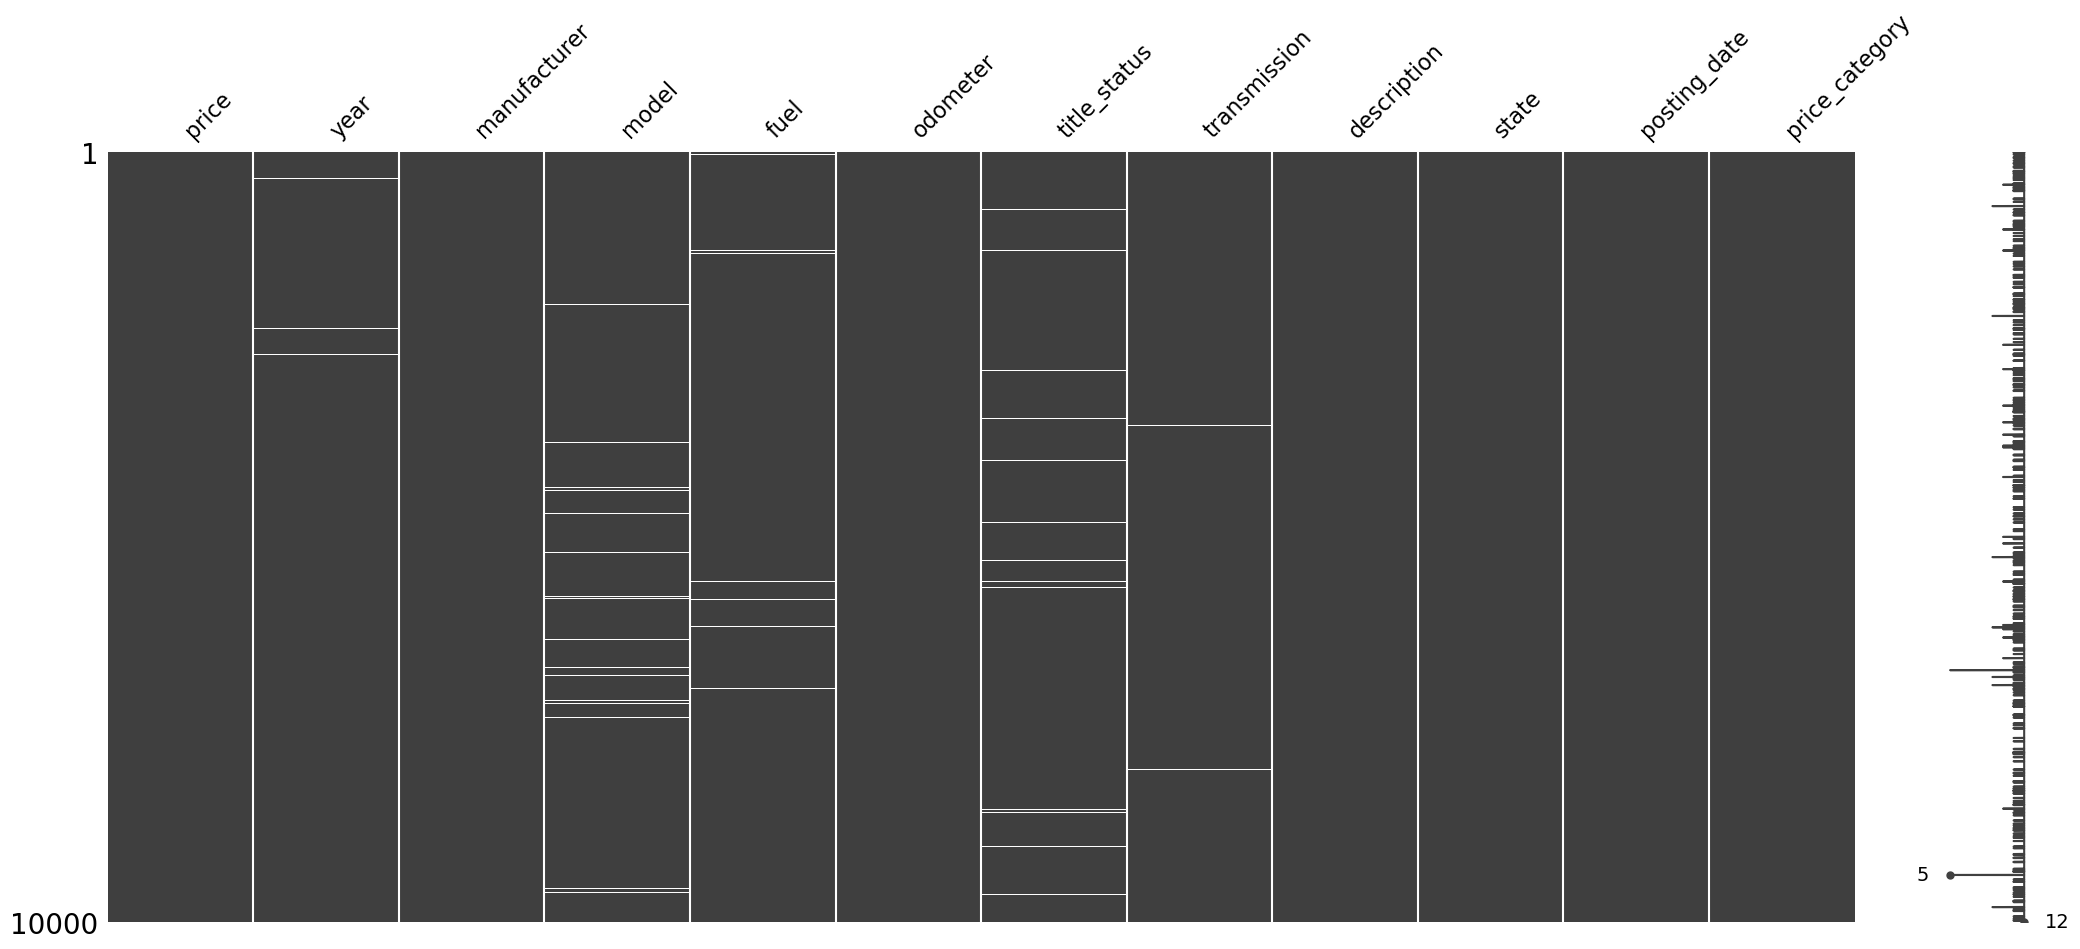

In [8]:
msno.matrix(df);

In [9]:
def check_missing(df):
    missing_counts = df.isna().sum()
    missing_values = ((missing_counts / len(df)) * 100)
    missing_df = pd.DataFrame({
        'Количество пропусков': missing_counts,
        'Процент пропусков': missing_values
    })
    missing_df = missing_df[missing_df['Количество пропусков'] > 0]
    missing_df = missing_df.sort_values('Количество пропусков', ascending=False)
    return missing_df

missing_df = check_missing(df)
missing_df

,Количество пропусков,Процент пропусков
title_status,166,1.66
model,128,1.28
fuel,63,0.63
transmission,45,0.45
year,36,0.36
description,2,0.02
posting_date,2,0.02


### 2.3.2 заполнение пропусков 'title_status'

In [10]:
df_missing_title = df[df['title_status'].isna()]
df_missing_title

,price,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,posting_date,price_category
11,4995,2012.0,fiat,500 pop,gas,59242,NaN,manual,"2012 Fiat 500 Pop FOR ONLY $102/mo!59,242 mi. ...",oh,2021-05-03T21:03:32-0400,low
187,17900,2013.0,ram,1500 tradesman quad cab,gas,145499,NaN,automatic,2013 Ram 1500 Tradesman Quad Cab PRICED TO SEL...,ca,2021-04-27T15:03:47-0700,medium
245,40990,2019.0,toyota,sienna xle,gas,3700,NaN,automatic,2019 Toyota Sienna - Wheelchair Accessible Han...,fl,2021-05-01T06:35:56-0400,high
286,4592,2003.0,chevrolet,avalanche 1500,gas,268691,NaN,automatic,$73/mo - 2003 Chevrolet Avalanche 1500 BaseCre...,oh,2021-04-14T12:03:01-0400,low
312,18450,2017.0,ford,mustang,gas,66049,NaN,automatic,"2017 Ford MUSTANG - $18,450 \tMayberry Motors ...",or,2021-04-16T04:06:29-0700,medium
...,...,...,...,...,...,...,...,...,...,...,...,...
9740,8995,2013.0,honda,odyssey,gas,203112,NaN,automatic,"2013 *Honda* *Odyssey* 5dr EX Van FWD - $8,995...",tn,2021-04-04T13:12:27-0400,low
9805,8900,2012.0,honda,accord,NaN,95674,NaN,NaN,Car Starz Call Sales at 717-401-4221 2012 Hond...,pa,2021-04-28T14:25:32-0400,low
9840,20900,2014.0,lexus,rx 350,gas,70800,NaN,automatic,2014 *Lexus* *RX 350* 2014 LEXUS RX 350 SUV 1-...,tn,2021-04-30T15:00:48-0500,medium
9856,11495,2006.0,lexus,gx 470,gas,242000,NaN,automatic,"2006 *Lexus* *GX 470* 4dr SUV 4WD - $11,495By ...",ga,2021-04-20T08:01:49-0400,medium


In [11]:
print(df.groupby('price_category')['title_status'].apply(lambda x: x.isna().mean() * 100))
print(df.groupby('price_category')['title_status'].apply(lambda x: x.isna().sum()))

price_category
high      0.886981
low       2.015504
medium    2.134146
Name: title_status, dtype: float64
price_category
high      31
low       65
medium    70
Name: title_status, dtype: int64


In [12]:
# не нашел логики или закономерности, заполним пропуски значением unknown
print(f"Пропусков в title_status до обработки: {df['title_status'].isna().sum()}")

df['title_status'] = df['title_status'].fillna('unknown')

print(f"Пропусков в title_status после обработки: {df['title_status'].isna().sum()}")
print(f"Новые уникальные значения 'title_status': {df['title_status'].unique()}")
df.shape

Пропусков в title_status до обработки: 166
Пропусков в title_status после обработки: 0
Новые уникальные значения 'title_status': ['clean' 'unknown' 'rebuilt' 'salvage' 'lien' 'missing' 'parts only']


(10000, 12)

### 2.3.3 заполнение пропусков 'model' (доработка 'manufacturer')

In [13]:
df_missing_model = df[df['model'].isna()]
len(df_missing_model)

128

In [14]:
len(df[df['manufacturer'] == 'other'])

382

In [15]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = re.sub(r'[^\w\s.,-]', '', str(text))  
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [16]:
df['model'] = df['model'].fillna('').apply(clean_text)
df['description'] = df['description'].fillna('').apply(clean_text)

In [17]:
print(f"Строк 'manufacturer' с 'other' до нормализации: {(df['manufacturer'].str.lower() == 'other').sum()}")

manufacturers = [m for m in df['manufacturer'].dropna().unique() if m.lower() != 'other']

def normalize_manufacturer(row):
    if row['manufacturer'].lower() != 'other':
        return row['manufacturer']
    
    combined_text = f"{row['model']} {row['description']}".lower()
    for m in manufacturers:
        if m.lower() in combined_text:
            return m
    return 'other'

df['manufacturer'] = df.apply(normalize_manufacturer, axis=1)
print(f"Строк 'manufacturer' с 'other' после нормализации: {(df['manufacturer'].str.lower() == 'other').sum()}")

Строк 'manufacturer' с 'other' до нормализации: 382
Строк 'manufacturer' с 'other' после нормализации: 153


In [18]:
manufacturer_models = {}
for m in df['manufacturer'].dropna().unique():
    if m.lower() == 'other':
        continue
    models = df.loc[df['manufacturer'] == m, 'model'].unique().tolist()
    manufacturer_models[m] = models

In [19]:
empty_model_before = df[df['model'].str.strip() == ''].index
print(f"Пустых моделей до заполнения: {len(empty_model_before)}")

def fill_model_from_description(row, manufacturer_models):
    if row['model'].strip():
        return row['model']
    
    manufacturer = row['manufacturer']
    if manufacturer.lower() == 'other':
        return row['model'] 
    
    desc = row['description']
    models = manufacturer_models.get(manufacturer, [])
    
    for m in models:
        words = m.split()
        for i in range(len(words)):
            for j in range(i+1, min(i+4, len(words)+1)):
                fragment = ' '.join(words[i:j])
                if fragment in desc:
                    return m  
    
    return row['model']  

df['model'] = df.apply(fill_model_from_description, axis=1, args=(manufacturer_models,))

empty_model_after = df[df['model'].str.strip() == ''].index
print(f"Пустых моделей после заполнения: {len(empty_model_after)}")

Пустых моделей до заполнения: 129
Пустых моделей после заполнения: 5


In [20]:
model_counts = df['model'].value_counts()
print("10 самых частых моделей:")
print(model_counts.head(10))

display(df.loc[empty_model_after].head(20))

10 самых частых моделей:
model
f-150             154
silverado 1500    112
1500              100
camry              77
grand cherokee     74
wrangler           74
silverado          74
escape             72
accord             69
civic              69
Name: count, dtype: int64


,price,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,posting_date,price_category
784,12500,1955.0,mercury,,gas,61000,clean,manual,1955 mercury custom original car. new interior...,va,2021-04-29T10:36:16-0400,medium
6728,3750,NaN,other,,NaN,95674,unknown,NaN,,nh,NaN,low
8744,25000,1969.0,mercury,,gas,23233,clean,automatic,1969 mercury montego mx convertible. excellent...,oh,2021-04-15T20:43:14-0400,high
8745,85500,2010.0,ferrari,,other,14548,clean,automatic,2010 ferrari california gt presented by auto h...,ks,2021-04-07T14:17:17-0500,high
9388,11999,NaN,other,,NaN,95674,unknown,NaN,,wa,NaN,medium


In [21]:
display(df[df['manufacturer'].isin(['mercury', 'ferrari'])].sort_values('manufacturer'))

,price,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,posting_date,price_category
292,239995,2017.0,ferrari,488 gtb,gas,6012,clean,automatic,2017 ferrari 488 gtb coupe2017 ferrari 488 gtb...,az,2021-04-22T09:38:59-0700,high
5149,129995,2007.0,ferrari,f430 spider,gas,12351,clean,manual,2007 ferrari f430 spider 2dr convertible offer...,ma,2021-04-29T14:45:08-0400,high
5347,14000,1995.0,ferrari,f50,gas,80000,clean,other,1995-1997 ferrari f50 replica . motor replaced...,tn,2021-04-28T21:18:07-0500,medium
8745,85500,2010.0,ferrari,,other,14548,clean,automatic,2010 ferrari california gt presented by auto h...,ks,2021-04-07T14:17:17-0500,high
5574,3495,2004.0,mercury,sable,gas,163288,clean,automatic,2004 mercury sable ls premium 4dr sedan offere...,id,2021-04-06T20:31:27-0600,low
6137,21500,1947.0,mercury,grand marquis ls,gas,30000,clean,automatic,47 mercury restorod 302c6 4 wheel disc brake ....,nc,2021-04-25T17:14:08-0400,medium
6151,5200,2009.0,mercury,grand marquis flex fuel,gas,96000,clean,automatic,2009 mercury grand marquis ls flex fuel 96k mi...,fl,2021-05-04T17:08:40-0400,low
6652,10500,1963.0,mercury,comet,gas,46140,clean,manual,the comet is a good quality fun driver it has ...,va,2021-05-02T22:17:45-0400,medium
6713,2200,2007.0,mercury,milan,gas,185958,clean,automatic,"for sale is a mint 2007 mercury milan 185,xxx ...",wi,2021-04-30T16:21:23-0500,low
8021,5499,1999.0,mercury,grand marquis ls,gas,156292,clean,automatic,"1999 mercury grand marquis ls156,292 mi. - aut...",ca,2021-04-29T12:31:24-0700,low


In [22]:
df.loc[8745, 'model'] = 'california gt' 
df.loc[784, 'model'] = 'custom'         
df.loc[8744, 'model'] = 'montego mx'    
df = df.drop(index=[6728, 9388]).reset_index(drop=True)

### 2.3.4 обработка пропусков 'year'

In [23]:
missing_df = check_missing(df)
missing_df

,Количество пропусков,Процент пропусков
fuel,61,0.610122
transmission,43,0.430086
year,34,0.340068


In [24]:
existing_years = df['year'].dropna()
min_year = int(existing_years.min())
max_year = int(existing_years.max())
print(f"Диапазон лет в данных: {min_year}-{max_year}")

def find_year_in_desc(description):
    if pd.isna(description):
        return None
    matches = re.findall(r'\b(\d{4})\b', str(description))
    for match in matches:
        year = int(match)
        if min_year <= year <= max_year:
            return year
    return None

year_null_indices = df[df['year'].isna()].index
print(f"Строк для обработки: {len(year_null_indices)}")

results = {'small_range': 0, 'from_desc': 0, 'mode': 0, 'not_filled': 0}

for idx in year_null_indices:
    model = df.loc[idx, 'model']
    price_cat = df.loc[idx, 'price_category']
    filled = False

    similar = df[
        (df['model'] == model) &
        (df['price_category'] == price_cat) &
        (df['year'].notna())
    ]

    if not similar.empty:
        years = similar['year'].dropna()
        year_range = years.max() - years.min()

        if year_range < 5:
            df.loc[idx, 'year'] = int(years.median())
            results['small_range'] += 1
            filled = True

    if not filled:
        year_from_desc = find_year_in_desc(df.loc[idx, 'description'])
        if year_from_desc:
            df.loc[idx, 'year'] = year_from_desc
            results['from_desc'] += 1
            filled = True

    if not filled and not similar.empty:
        mode_year = years.mode()
        if not mode_year.empty:
            df.loc[idx, 'year'] = int(mode_year.iloc[0])
            results['mode'] += 1
            filled = True

    if not filled:
        results['not_filled'] += 1

print(f"\nРезультаты:")
print(f"  Маленький разброс: {results['small_range']}")
print(f"  Из описания: {results['from_desc']}")
print(f"  Мода: {results['mode']}")
print(f"  Не заполнено : {results['not_filled']}")
print(f"\nИтог: пропусков year: {df['year'].isna().sum()}")

Диапазон лет в данных: 1915-2022
Строк для обработки: 34

Результаты:
  Маленький разброс: 12
  Из описания: 22
  Мода: 0
  Не заполнено : 0

Итог: пропусков year: 0


In [25]:
df.head()

,price,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,posting_date,price_category
0,54990,2020.0,ram,2500 crew cab big horn,diesel,27442,clean,other,carvana is the safer way to buy a car during t...,tn,2021-04-17T12:30:50-0400,high
1,16942,2016.0,ford,explorer 4wd 4dr xlt,NaN,60023,clean,automatic,call us for more information at 201-635-1400 v...,nj,2021-05-03T15:40:21-0400,medium
2,35590,2017.0,volkswagen,golf r hatchback,gas,14048,clean,other,carvana is the safer way to buy a car during t...,ca,2021-04-28T03:52:20-0700,high
3,14500,2013.0,toyota,rav4,gas,117291,clean,automatic,2013 toyota rav4 xle 4dr suv offered by reliab...,nc,2021-04-17T10:08:57-0400,medium
4,21800,2021.0,nissan,altima,gas,8000,clean,automatic,2021 nissan altima sv with only 8 k miles titl...,ny,2021-05-03T18:32:06-0400,medium


In [26]:
df.dropna(subset=['year'])
df.shape

(9998, 12)

### 2.3.5 обработка пропусков 'fuel'

In [27]:
missing_df = check_missing(df)
missing_df

,Количество пропусков,Процент пропусков
fuel,61,0.610122
transmission,43,0.430086


In [28]:
unique_fuel_values = df['fuel'].dropna().unique()
unique_fuel_values

array(['diesel', 'gas', 'other', 'electric', 'hybrid'], dtype=object)

In [29]:
fuel_types = ['diesel', 'gas', 'electric', 'hybrid']

empty_count = df['fuel'].isna().sum()
other_count = (df['fuel'] == 'other').sum()
print(f"Количество пустых до поиска в 'description': {empty_count}")
print(f"Количество 'other' до поиска в 'description': {other_count}")

def fill_fuel_from_description(row):
    desc = str(row['description']).lower()
    found = [f for f in fuel_types if f in desc]
    
    if pd.isna(row['fuel']):
        if len(found) == 1:
            return found[0]
        return None
    elif row['fuel'] == 'other':
        if len(found) == 1:
            return found[0]
        return 'other'
    else:
        return row['fuel']

df['fuel'] = df.apply(fill_fuel_from_description, axis=1)

empty_count = df['fuel'].isna().sum()
other_count = (df['fuel'] == 'other').sum()

print(f"Количество пустых после описания: {empty_count}")
print(f"Количество 'other' после описания: {other_count}")

Количество пустых до поиска в 'description': 61
Количество 'other' до поиска в 'description': 730
Количество пустых после описания: 40
Количество 'other' после описания: 594


In [30]:
method_counts = {
    'manufacturer+model+year': 0,
    'manufacturer+model': 0,
    'manufacturer+year': 0,
    'manufacturer_only': 0,
    'general_mode': 0
}

In [31]:
def fill_by_mode(row):
    if pd.notna(row['fuel']):
        return row['fuel']
    
    # manufacturer + model + year
    subset = df[(df['manufacturer'] == row['manufacturer']) &
                (df['model'] == row['model']) &
                (df['year'] == row['year']) &
                (df['fuel'].notna()) &
                (df['fuel'] != 'other')]
    if not subset.empty:
        method_counts['manufacturer+model+year'] += 1
        return subset['fuel'].mode()[0]
    
    # manufacturer + model
    subset = df[(df['manufacturer'] == row['manufacturer']) &
                (df['model'] == row['model']) &
                (df['fuel'].notna()) &
                (df['fuel'] != 'other')]
    if not subset.empty:
        method_counts['manufacturer+model'] += 1
        return subset['fuel'].mode()[0]
    
    # manufacturer + year
    subset = df[(df['manufacturer'] == row['manufacturer']) &
                (df['year'] == row['year']) &
                (df['fuel'].notna()) &
                (df['fuel'] != 'other')]
    if not subset.empty:
        method_counts['manufacturer+year'] += 1
        return subset['fuel'].mode()[0]
    
    # manufacturer only
    subset = df[(df['manufacturer'] == row['manufacturer']) &
                (df['fuel'].notna()) &
                (df['fuel'] != 'other')]
    if not subset.empty:
        method_counts['manufacturer_only'] += 1
        return subset['fuel'].mode()[0]
    
    # common mode
    method_counts['general_mode'] += 1
    return df[df['fuel'].notna() & (df['fuel'] != 'other')]['fuel'].mode()[0]

df['fuel'] = df.apply(fill_by_mode, axis=1)

empty_count_final = df['fuel'].isna().sum()
other_count_final = (df['fuel'] == 'other').sum()
print(f"Количество пустых после заполнения: {empty_count_final}")
print(f"Количество 'other' после заполнения: {other_count_final}")
print(f"Заполнение по методам: {method_counts}")

Количество пустых после заполнения: 0
Количество 'other' после заполнения: 594
Заполнение по методам: {'manufacturer+model+year': 10, 'manufacturer+model': 5, 'manufacturer+year': 25, 'manufacturer_only': 0, 'general_mode': 0}


In [32]:
fuel_types = ['diesel', 'gas', 'electric', 'hybrid']

def fuels_in_description(text):
    text = str(text).lower()
    found = [f for f in fuel_types if f in text]
    return found

mask = df['fuel'].isna() | (df['fuel'] == 'other')
df_fuel_multiple = df[mask].copy()

df_fuel_multiple['fuels_found'] = df_fuel_multiple['description'].apply(fuels_in_description)

df_fuel_multiple = df_fuel_multiple[df_fuel_multiple['fuels_found'].apply(len) > 1]

display(df_fuel_multiple[['fuel', 'description', 'fuels_found']])
print(f"Количество строк с несколькими упоминаниями топлива: {len(df_fuel_multiple)}")

,fuel,description,fuels_found
131,other,"2017 ram 1500 slt 4x4 quad cab 64 box -- 9,500...","[diesel, electric]"
234,other,2015 ford f-250 f250 f 250 super duty xlt 4x4 ...,"[diesel, gas]"
1006,other,carvana is the safer way to buy a car during t...,"[electric, hybrid]"
1126,other,2012 kia_ optima_ hybrid offered by a better w...,"[gas, electric, hybrid]"
1685,other,2014 chevrolet chevy silverado 1500 lt 4x4 4dr...,"[diesel, gas]"
1863,other,carvana is the safer way to buy a car during t...,"[electric, hybrid]"
2072,other,2013 ford f-450 super duty 4x2 4dr supercab 16...,"[diesel, gas]"
2448,other,_chevrolet_suburban_roy robinson chevrolet ---...,"[gas, electric]"
2588,other,2015 lincoln mkz base sedan - stock 112791s lo...,"[electric, hybrid]"
3265,other,vehicle description stock wyc-a50792 actual lo...,"[diesel, gas, electric, hybrid]"


Количество строк с несколькими упоминаниями топлива: 29


### 2.3.6 обработка пропусков 'transmission'

In [33]:
missing_df = check_missing(df)
missing_df

,Количество пропусков,Процент пропусков
transmission,43,0.430086


In [34]:
unique_trans_values = df['transmission'].dropna().unique()
unique_trans_values

array(['other', 'automatic', 'manual'], dtype=object)

In [35]:
trans_types = ['automatic', 'manual']

missing_trans = df[df['transmission'].isna()]
other_trans = df[df['transmission'] == 'other']
print(f"Пропусков в transmission до обработки: {len(missing_trans)}")
print(f"'Other' в transmission до обработки: {len(other_trans)}")

Пропусков в transmission до обработки: 43
'Other' в transmission до обработки: 1624


In [36]:
def fill_trans_from_description(row):
    if pd.notna(row['transmission']) and row['transmission'] not in [None, 'other']:
        return row['transmission']

    desc = str(row['description']).lower()
    found = [t for t in trans_types if t in desc]

    if len(found) == 1:
        return found[0]

    return row['transmission']

df['transmission'] = df.apply(fill_trans_from_description, axis=1)

In [37]:
empty_count = df['transmission'].isna().sum()
other_count = (df['transmission'] == 'other').sum()
print(f"Количество пустых после поиска в description: {empty_count}")
print(f"Количество 'other' после поиска в description: {other_count}")

Количество пустых после поиска в description: 37
Количество 'other' после поиска в description: 124


In [38]:
methods_counts = {
    'manufacturer+model+year': 0,
    'manufacturer+model': 0,
    'manufacturer+year': 0,
    'manufacturer_only': 0,
    'general_mode': 0
}

In [39]:
def fill_remaining_trans(row):
    global methods_counts
    if pd.notna(row['transmission']) and row['transmission'] != 'other':
        return row['transmission']  

    if pd.isna(row['transmission']):
        # manufacturer+model+year
        subset = df[
            (df['manufacturer'] == row['manufacturer']) &
            (df['model'] == row['model']) &
            (df['year'] == row['year']) &
            (df['transmission'].notna()) &
            (df['transmission'] != 'other')
        ]
        if len(subset) > 0:
            mode_val = subset['transmission'].mode()
            if len(mode_val) > 0:
                methods_counts['manufacturer+model+year'] += 1
                return mode_val[0]

        # manufacturer+model
        subset = df[
            (df['manufacturer'] == row['manufacturer']) &
            (df['model'] == row['model']) &
            (df['transmission'].notna()) &
            (df['transmission'] != 'other')
        ]
        if len(subset) > 0:
            mode_val = subset['transmission'].mode()
            if len(mode_val) > 0:
                methods_counts['manufacturer+model'] += 1
                return mode_val[0]

        # manufacturer+year
        subset = df[
            (df['manufacturer'] == row['manufacturer']) &
            (df['year'] == row['year']) &
            (df['transmission'].notna()) &
            (df['transmission'] != 'other')
        ]
        if len(subset) > 0:
            mode_val = subset['transmission'].mode()
            if len(mode_val) > 0:
                methods_counts['manufacturer+year'] += 1
                return mode_val[0]

        # manufacturer only
        subset = df[
            (df['manufacturer'] == row['manufacturer']) &
            (df['transmission'].notna()) &
            (df['transmission'] != 'other')
        ]
        if len(subset) > 0:
            mode_val = subset['transmission'].mode()
            if len(mode_val) > 0:
                methods_counts['manufacturer_only'] += 1
                return mode_val[0]

        # general mode
        mode_val = df[df['transmission'].notna() & (df['transmission'] != 'other')]['transmission'].mode()
        if len(mode_val) > 0:
            methods_counts['general_mode'] += 1
            return mode_val[0]

    # оставляем как есть (None или 'other')
    return row['transmission']

df['transmission'] = df.apply(fill_remaining_trans, axis=1)

empty_count = df['transmission'].isna().sum()
other_count = (df['transmission'] == 'other').sum()
print(f"Количество пустых после заполнения: {empty_count}")
print(f"Количество 'other' после заполнения: {other_count}")
print(f"Заполнение по методам: {methods_counts}")

Количество пустых после заполнения: 0
Количество 'other' после заполнения: 124
Заполнение по методам: {'manufacturer+model+year': 22, 'manufacturer+model': 11, 'manufacturer+year': 3, 'manufacturer_only': 1, 'general_mode': 0}


In [40]:
missing_df = check_missing(df)
missing_df

,Количество пропусков,Процент пропусков


In [41]:
columns_to_check = df.columns.tolist()  

other_counts = {col: (df[col] == 'other').sum() for col in columns_to_check}

print("Количество 'other' в колонках:")
for col, count in other_counts.items():
    print(f"{col}: {count}")

Количество 'other' в колонках:
price: 0
year: 0
manufacturer: 151
model: 0
fuel: 594
odometer: 0
title_status: 0
transmission: 124
description: 0
state: 0
posting_date: 0
price_category: 0


In [42]:
df.shape

(9998, 12)

In [43]:
df.head()

,price,year,manufacturer,model,fuel,odometer,title_status,transmission,description,state,posting_date,price_category
0,54990,2020.0,ram,2500 crew cab big horn,diesel,27442,clean,automatic,carvana is the safer way to buy a car during t...,tn,2021-04-17T12:30:50-0400,high
1,16942,2016.0,ford,explorer 4wd 4dr xlt,gas,60023,clean,automatic,call us for more information at 201-635-1400 v...,nj,2021-05-03T15:40:21-0400,medium
2,35590,2017.0,volkswagen,golf r hatchback,gas,14048,clean,automatic,carvana is the safer way to buy a car during t...,ca,2021-04-28T03:52:20-0700,high
3,14500,2013.0,toyota,rav4,gas,117291,clean,automatic,2013 toyota rav4 xle 4dr suv offered by reliab...,nc,2021-04-17T10:08:57-0400,medium
4,21800,2021.0,nissan,altima,gas,8000,clean,automatic,2021 nissan altima sv with only 8 k miles titl...,ny,2021-05-03T18:32:06-0400,medium


## 2.4 преобразование типов данных

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           9998 non-null   int64  
 1   year            9998 non-null   float64
 2   manufacturer    9998 non-null   object 
 3   model           9998 non-null   object 
 4   fuel            9998 non-null   object 
 5   odometer        9998 non-null   int64  
 6   title_status    9998 non-null   object 
 7   transmission    9998 non-null   object 
 8   description     9998 non-null   object 
 9   state           9998 non-null   object 
 10  posting_date    9998 non-null   object 
 11  price_category  9998 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 937.4+ KB


In [45]:
df['year'] = df['year'].astype('Int64') 
df['posting_date'] = pd.to_datetime(df['posting_date'], utc=True)
df['price_category'] = df['price_category'].astype('category')

In [46]:
df.dtypes

price                           int64
year                            Int64
manufacturer                   object
model                          object
fuel                           object
odometer                        int64
title_status                   object
transmission                   object
description                    object
state                          object
posting_date      datetime64[ns, UTC]
price_category               category
dtype: object

## 2.5 обработка аномалий

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   price           9998 non-null   int64              
 1   year            9998 non-null   Int64              
 2   manufacturer    9998 non-null   object             
 3   model           9998 non-null   object             
 4   fuel            9998 non-null   object             
 5   odometer        9998 non-null   int64              
 6   title_status    9998 non-null   object             
 7   transmission    9998 non-null   object             
 8   description     9998 non-null   object             
 9   state           9998 non-null   object             
 10  posting_date    9998 non-null   datetime64[ns, UTC]
 11  price_category  9998 non-null   category           
dtypes: Int64(1), category(1), datetime64[ns, UTC](1), int64(2), object(7)
memory usage: 879.0+

### 2.5.1 обработка аномалий 'price'

In [48]:
df['price_original'] = df['price']

print("\nОсновная статистика до обработки:")
print(f"Всего записей: {len(df):,}")
print(f"Диапазон цен: [{df['price_original'].min():,}, {df['price_original'].max():,}]")
print(f"Медиана: {df['price_original'].median():,.0f}")
print(f"Среднее: {df['price_original'].mean():,.0f}")
print(f"Стандартное отклонение: {df['price_original'].std():,.0f}")


Основная статистика до обработки:
Всего записей: 9,998
Диапазон цен: [500, 12,345,678]
Медиана: 15,756
Среднее: 20,681
Стандартное отклонение: 124,635


In [49]:
placeholder_prices = [12345678, 1000000]
for price in placeholder_prices:
    mask = df['price'] == price
    if mask.sum() > 0:
        df.loc[mask, 'price'] = np.nan

In [50]:
category_bounds = {}
for category in df['price_category'].unique():
    cat_prices = df.loc[df['price_category']==category, 'price_original'].dropna()
    Q1 = cat_prices.quantile(0.25)
    Q3 = cat_prices.quantile(0.75)
    IQR = Q3 - Q1

    if category == 'high':
        lower = max(0, Q1 - 1.5 * IQR)
        upper = cat_prices.quantile(0.997)
    elif category == 'medium':
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
    else:  # low
        lower = max(0, Q1 - 1.5 * IQR)
        upper = Q3 + 1.5 * IQR

    category_bounds[category] = {'lower': lower, 'upper': upper}

    cat_mask = df['price_category'] == category
    df.loc[cat_mask, 'price'] = df.loc[cat_mask, 'price'].clip(lower=lower, upper=upper).astype('float')

In [51]:
for category in df['price_category'].unique():
    cat_mask = (df['price_category']==category) & (df['price'].isna())
    median_price = df.loc[df['price_category']==category, 'price'].median()
    df.loc[cat_mask, 'price'] = median_price

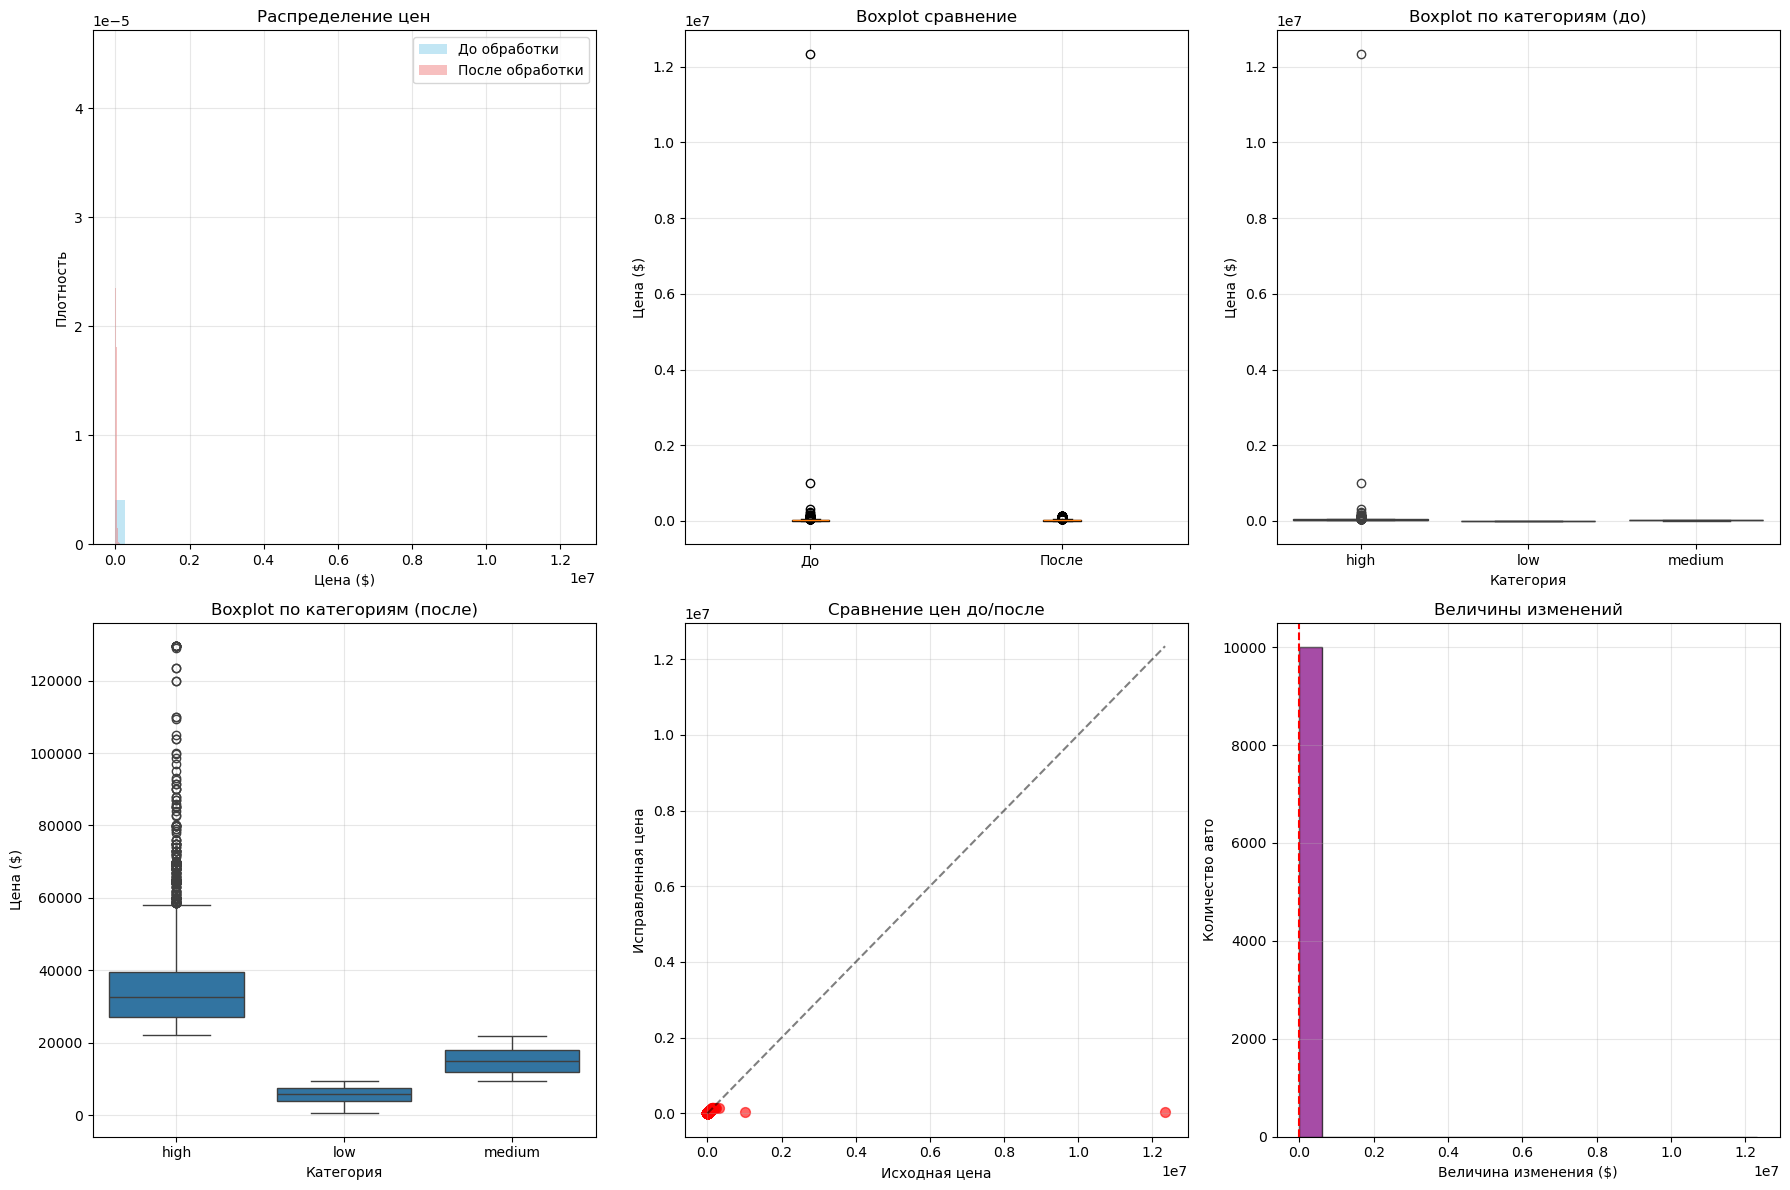

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].hist(df['price_original'], bins=50, alpha=0.5, color='skyblue', density=True, label='До обработки')
axes[0, 0].hist(df['price'], bins=50, alpha=0.5, color='lightcoral', density=True, label='После обработки')
axes[0, 0].set_title('Распределение цен')
axes[0, 0].set_xlabel('Цена ($)')
axes[0, 0].set_ylabel('Плотность')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].boxplot([df['price_original'], df['price']], patch_artist=True, tick_labels=['До', 'После'])
axes[0, 1].set_title('Boxplot сравнение')
axes[0, 1].set_ylabel('Цена ($)')
axes[0, 1].grid(alpha=0.3)

sns.boxplot(x='price_category', y='price_original', data=df, ax=axes[0, 2], dodge=False)
axes[0, 2].set_title('Boxplot по категориям (до)')
axes[0, 2].set_xlabel('Категория')
axes[0, 2].set_ylabel('Цена ($)')
axes[0, 2].grid(alpha=0.3)

sns.boxplot(x='price_category', y='price', data=df, ax=axes[1, 0], dodge=False)
axes[1, 0].set_title('Boxplot по категориям (после)')
axes[1, 0].set_xlabel('Категория')
axes[1, 0].set_ylabel('Цена ($)')
axes[1, 0].grid(alpha=0.3)

axes[1, 1].scatter(df['price_original'], df['price'], alpha=0.6, color='red', s=50)
max_val = max(df['price_original'].max(), df['price'].max())
axes[1, 1].plot([0, max_val], [0, max_val], 'k--', alpha=0.5)
axes[1, 1].set_title('Сравнение цен до/после')
axes[1, 1].set_xlabel('Исходная цена')
axes[1, 1].set_ylabel('Исправленная цена')
axes[1, 1].grid(alpha=0.3)

price_changes = df['price_original'] - df['price']
axes[1, 2].hist(price_changes, bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[1, 2].axvline(0, color='red', linestyle='--')
axes[1, 2].set_title('Величины изменений')
axes[1, 2].set_xlabel('Величина изменения ($)')
axes[1, 2].set_ylabel('Количество авто')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
changed_mask = df['price_original'] != df['price']
print("\nФинальная статистика:")
print(f"Всего записей: {len(df):,}")
print(f"Изменено цен: {changed_mask.sum():,} ({changed_mask.sum()/len(df)*100:.2f}%)")
print(f"Диапазон цен: [{df['price'].min():,.0f}, {df['price'].max():,.0f}]")
print(f"Медиана: {df['price'].median():,.0f}")
print(f"Среднее: {df['price'].mean():,.0f}")


Финальная статистика:
Всего записей: 9,998
Изменено цен: 11 (0.11%)
Диапазон цен: [500, 129,515]
Медиана: 15,756
Среднее: 19,309


In [54]:
df.drop(columns=['price_original'], inplace=True)

In [55]:
df.shape

(9998, 12)

### 2.5.2 обработка аномалий 'year'

In [56]:
df['year_original'] = df['year'].copy()

In [57]:
YEAR_MIN = 1886
YEAR_MAX = datetime.now().year

print('Границы для year:')
print(f'  Минимум: {YEAR_MIN}')
print(f'  Максимум: {YEAR_MAX}')

Границы для year:
  Минимум: 1886
  Максимум: 2025


In [58]:
mask_low = df['year'] < YEAR_MIN
mask_high = df['year'] > YEAR_MAX
mask_na = df['year'].isna()

print('Найдено аномалий:')
print(f'  Ниже минимума: {mask_low.sum()}')
print(f'  Выше максимума: {mask_high.sum()}')
print(f'  NaN:            {mask_na.sum()}')

Найдено аномалий:
  Ниже минимума: 0
  Выше максимума: 0
  NaN:            0


In [59]:
df.loc[mask_low, 'year'] = YEAR_MIN
df.loc[mask_high, 'year'] = YEAR_MAX

year_median = df['year'].median()
df.loc[mask_na, 'year'] = year_median

changed_mask = df['year'] != df['year_original']

print('Результат обработки:')
print(f'  Всего изменено: {changed_mask.sum()} авто '
      f'({changed_mask.sum() / len(df) * 100:.2f}%)')

Результат обработки:
  Всего изменено: 0 авто (0.00%)


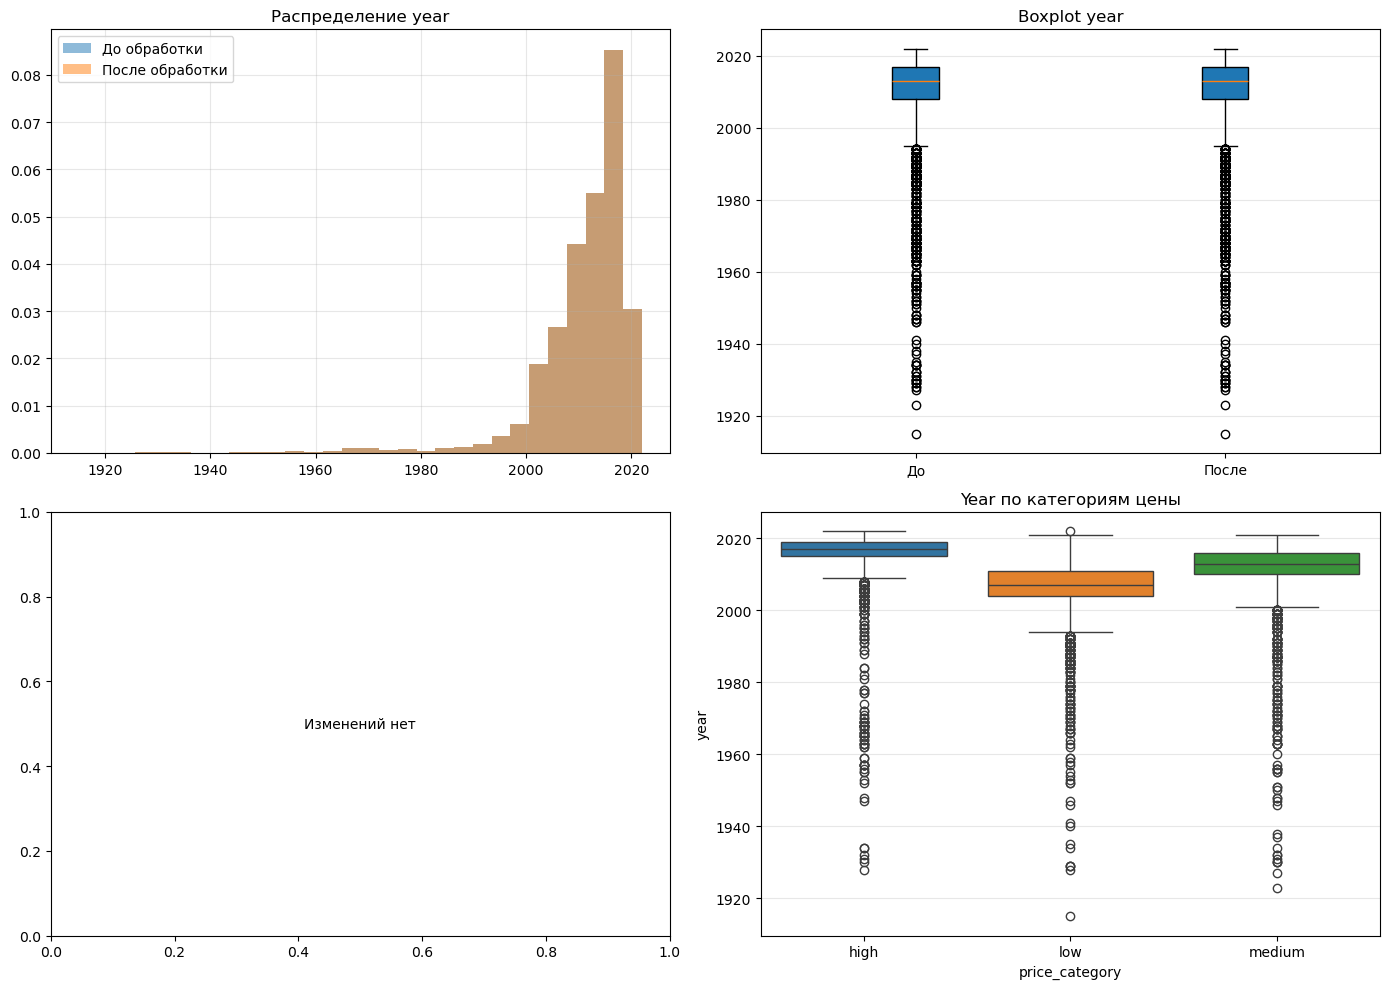

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['year_original'], bins=30, alpha=0.5, density=True,
                label='До обработки')
axes[0, 0].hist(df['year'], bins=30, alpha=0.5, density=True,
                label='После обработки')
axes[0, 0].set_title('Распределение year')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].boxplot(
    [df['year_original'], df['year']],
    patch_artist=True,
    tick_labels=['До', 'После']
)
axes[0, 1].set_title('Boxplot year')
axes[0, 1].grid(axis='y', alpha=0.3)

if changed_mask.any():
    changed_data = df[changed_mask]
    axes[1, 0].scatter(
        changed_data['year_original'],
        changed_data['year'],
        alpha=0.6
    )
    axes[1, 0].plot(
        [YEAR_MIN, YEAR_MAX],
        [YEAR_MIN, YEAR_MAX],
        linestyle='--'
    )
    axes[1, 0].set_title('Изменённые значения year')
    axes[1, 0].set_xlabel('Исходный year')
    axes[1, 0].set_ylabel('Обработанный year')
    axes[1, 0].grid(alpha=0.3)
else:
    axes[1, 0].text(
        0.5, 0.5,
        'Изменений нет',
        ha='center',
        va='center',
        transform=axes[1, 0].transAxes
    )

sns.boxplot(
    x='price_category',
    y='year',
    hue='price_category',
    data=df,
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Year по категориям цены')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [61]:
print('Финальная статистика year:')
print(f'  Мин: {df["year"].min()}')
print(f'  Макс: {df["year"].max()}')
print(f'  Медиана: {df["year"].median()}')

Финальная статистика year:
  Мин: 1915
  Макс: 2022
  Медиана: 2013.0


In [62]:
df = df.drop(columns='year_original')
print('Удалён временный столбец: year_original')

Удалён временный столбец: year_original


### 2.5.3 обработка аномалий 'odometer'

In [63]:
df['odometer_original'] = df['odometer']

In [64]:
total_rows = len(df)
negatives = (df['odometer'] < 0).sum()
zeros = (df['odometer'] == 0).sum()
nans = df['odometer'].isna().sum()

print('Исходное состояние:')
print(f'  Всего записей:       {total_rows:}')
print(f'  Отрицательные значения: {negatives}')
print(f'  Нулевые значения:      {zeros}')
print(f'  NaN:                    {nans}')

Исходное состояние:
  Всего записей:       9998
  Отрицательные значения: 0
  Нулевые значения:      29
  NaN:                    0


In [65]:
Q1 = df['odometer'].quantile(0.25)
Q3 = df['odometer'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = 0
upper_iqr = Q3 + 1.5 * IQR
upper_percentile = df['odometer'].quantile(0.995)

upper_bound = min(upper_iqr, upper_percentile)

print('Границы обработки:')
print(f'  Нижняя: {lower_bound:.0f}')
print(f'  Верхняя (IQR): {upper_iqr:.0f}')
print(f'  Верхняя (99.5%): {upper_percentile:.0f}')
print(f'  Итоговая верхняя: {upper_bound:.0f}')

Границы обработки:
  Нижняя: 0
  Верхняя (IQR): 283472
  Верхняя (99.5%): 283466
  Итоговая верхняя: 283466


In [66]:
df['odometer'] = df['odometer'].clip(
    lower=lower_bound,
    upper=upper_bound
).astype('int64')

In [67]:
changed_mask = df['odometer'] != df['odometer_original']
changed_total = changed_mask.sum()
changed_lower = (df['odometer_original'] < lower_bound).sum()
changed_upper = (df['odometer_original'] > upper_bound).sum()

print('Результат обработки:')
print(f'  Ограничено снизу: {changed_lower}')
print(f'  Ограничено сверху: {changed_upper}')
print(f'  Всего изменено: {changed_total} ({changed_total / total_rows * 100:.2f}%)')

Результат обработки:
  Ограничено снизу: 0
  Ограничено сверху: 0
  Всего изменено: 0 (0.00%)


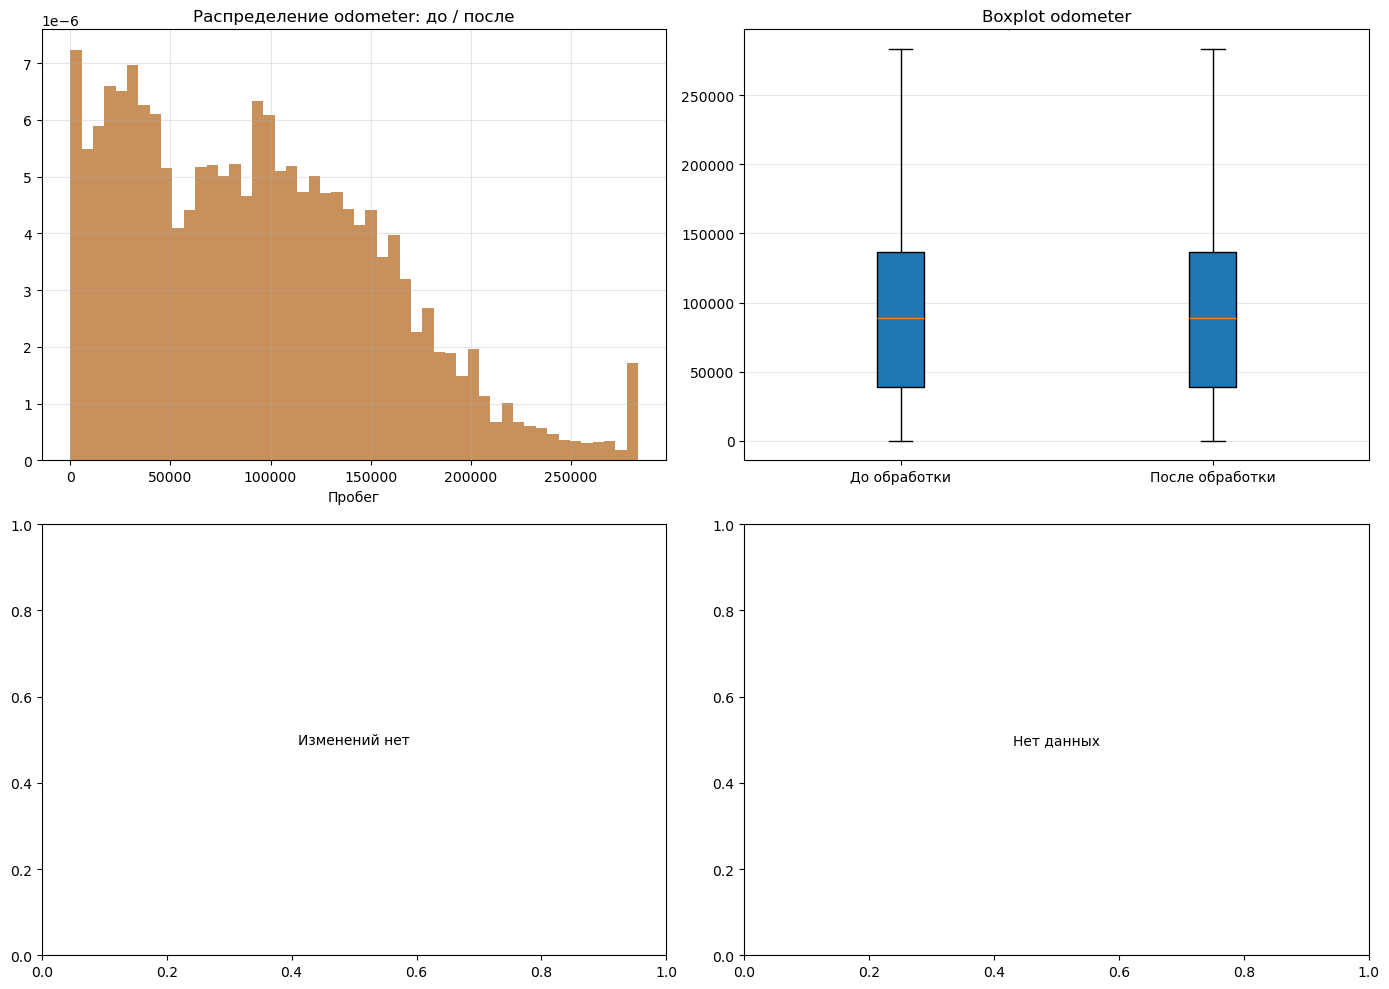

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['odometer_original'], bins=50, alpha=0.6, density=True)
axes[0, 0].hist(df['odometer'], bins=50, alpha=0.6, density=True)
axes[0, 0].set_title('Распределение odometer: до / после')
axes[0, 0].set_xlabel('Пробег')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot(
    [df['odometer_original'], df['odometer']],
    patch_artist=True,
    tick_labels=['До обработки', 'После обработки']
)
axes[0, 1].set_title('Boxplot odometer')
axes[0, 1].grid(True, axis='y', alpha=0.3)

if changed_total > 0:
    changed_df = df[changed_mask]
    axes[1, 0].scatter(
        changed_df['odometer_original'],
        changed_df['odometer'],
        alpha=0.6
    )
    max_val = max(
        changed_df['odometer_original'].max(),
        changed_df['odometer'].max()
    )
    axes[1, 0].plot([0, max_val], [0, max_val], linestyle='--')
    axes[1, 0].set_title('Изменённые значения')
    axes[1, 0].set_xlabel('Было')
    axes[1, 0].set_ylabel('Стало')
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(
        0.5, 0.5, 'Изменений нет',
        ha='center', va='center',
        transform=axes[1, 0].transAxes
    )

if changed_total > 0:
    deltas = df.loc[changed_mask, 'odometer_original'] - df.loc[changed_mask, 'odometer']
    axes[1, 1].hist(deltas, bins=30)
    axes[1, 1].set_title('Величина изменений')
    axes[1, 1].set_xlabel('Разница пробега')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(
        0.5, 0.5, 'Нет данных',
        ha='center', va='center',
        transform=axes[1, 1].transAxes
    )

plt.tight_layout()
plt.show()

In [69]:
print('Финальная статистика odometer:')
print(f'  Мин: {df["odometer"].min():,.0f}')
print(f'  Макс: {df["odometer"].max():,.0f}')
print(f'  Медиана: {df["odometer"].median():,.0f}')

Финальная статистика odometer:
  Мин: 0
  Макс: 283,466
  Медиана: 89,000


In [70]:
df.drop(columns='odometer_original', inplace=True)
print('Удалён временный столбец: odometer_original')

Удалён временный столбец: odometer_original


# 3. Feature engineering

## 3.1 Анализ признаков

### 3.1.1 categorical columns

In [71]:
def analyze_categorical_column(df, col, top_n=10, rare_threshold=20):
    print(f"Колонка: {col}")
    print(f"{'='*40}")
    
    total = len(df)
    nunique = df[col].nunique()
    nan_count = df[col].isna().sum()
    
    value_counts = df[col].value_counts()
    rare_count = (value_counts < rare_threshold).sum()
    rare_rows = value_counts[value_counts < rare_threshold].sum()
    
    print(f"Всего строк:        {total}")
    print(f"Уникальных значений:{nunique}")
    print(f"NaN:             {nan_count}")
    print(f"Редких категорий (<{rare_threshold}): {rare_count}")
    print(f"Строк с редкими: {rare_rows} ({rare_rows/total*100:.2f}%)")
    
    print("\nТоп значений:")
    print(value_counts.head(top_n))

In [72]:
analyze_categorical_column(df, 'manufacturer', rare_threshold=20)

Колонка: manufacturer
Всего строк:        9998
Уникальных значений:40
NaN:             0
Редких категорий (<20): 4
Строк с редкими: 24 (0.24%)

Топ значений:
manufacturer
ford         1660
chevrolet    1297
toyota        783
ram           560
jeep          493
honda         467
nissan        457
gmc           362
bmw           332
dodge         327
Name: count, dtype: int64


In [73]:
# manufacturer:
# пропусков нет
# кардинальность умеренная
# редкие категории < 1%
# оставить без изменений
# кодирование — позже

In [74]:
analyze_categorical_column(df, 'model', rare_threshold=20)

Колонка: model
Всего строк:        9998
Уникальных значений:3433
NaN:             0
Редких категорий (<20): 3361
Строк с редкими: 7102 (71.03%)

Топ значений:
model
f-150             154
silverado 1500    112
1500              100
camry              77
wrangler           74
grand cherokee     74
silverado          74
escape             72
accord             69
civic              69
Name: count, dtype: int64


In [75]:
# model:
# пропусков нет
# очень высокая кардинальность (3433 уникальных значения)
# ~71% строк — редкие категории (<20 наблюдений)
# сильный шум (комплектации, опечатки, разный порядок слов)
# автоматическая нормализация требует значительных усилий и несёт риск ошибок
# оставить без изменений
# кодирование — позже

In [76]:
analyze_categorical_column(df, 'fuel', rare_threshold=50)

Колонка: fuel
Всего строк:        9998
Уникальных значений:5
NaN:             0
Редких категорий (<50): 1
Строк с редкими: 49 (0.49%)

Топ значений:
fuel
gas         8482
diesel       708
other        594
hybrid       165
electric      49
Name: count, dtype: int64


In [77]:
# fuel:
# пропусков нет
# низкая кардинальность 
# одна редкая категория (~0.5% строк) — electric
# значения семантически корректны и устойчивы
# оставить без изменений
# кодирование — позже

In [78]:
analyze_categorical_column(df, 'title_status', rare_threshold=50)

Колонка: title_status
Всего строк:        9998
Уникальных значений:7
NaN:             0
Редких категорий (<50): 3
Строк с редкими: 53 (0.53%)

Топ значений:
title_status
clean         9518
rebuilt        171
unknown        164
salvage         92
lien            35
missing         16
parts only       2
Name: count, dtype: int64


In [79]:
# title_status:
# пропусков нет
# низкая кардинальность 
# редкие категории (~0.5% строк): lien, missing, parts only
# схлопнуть редкие категории в 'other' для упрощения модели
# сохранить основные значимые категории: clean, rebuilt, unknown, salvage
# кодирование — позже

In [80]:
rare_title_status = ['lien', 'missing', 'parts only']
df['title_status_reduced'] = df['title_status'].where(~df['title_status'].isin(rare_title_status), 'other')
df['title_status_reduced'].value_counts()

title_status_reduced
clean      9518
rebuilt     171
unknown     164
salvage      92
other        53
Name: count, dtype: int64

In [81]:
analyze_categorical_column(df, 'transmission', rare_threshold=50)

Колонка: transmission
Всего строк:        9998
Уникальных значений:3
NaN:             0
Редких категорий (<50): 0
Строк с редкими: 0 (0.00%)

Топ значений:
transmission
automatic    9223
manual        651
other         124
Name: count, dtype: int64


In [82]:
# transmission:
# пропусков нет
# кардинальность низкая
# редкие категории отсутствуют
# оставить без изменений
# кодирование — позже

In [83]:
analyze_categorical_column(df, 'state', rare_threshold=100)

Колонка: state
Всего строк:        9998
Уникальных значений:51
NaN:             0
Редких категорий (<100): 21
Строк с редкими: 1177 (11.77%)

Топ значений:
state
ca    1108
fl     682
tx     535
mi     461
ny     451
oh     410
pa     354
nc     349
or     332
wa     314
Name: count, dtype: int64


In [84]:
#state:
# пропусков нет
# кардинальность высокая
# редкие категории 
# схлопнуть редкие в «other» для упрощения
# кодирование — позже

In [85]:
rare_states = df['state'].value_counts()[df['state'].value_counts() < 100].index
df['state_reduced'] = df['state'].where(~df['state'].isin(rare_states), 'other')
df['state_reduced'].value_counts()

state_reduced
other    1177
ca       1108
fl        682
tx        535
mi        461
ny        451
oh        410
pa        354
nc        349
or        332
wa        314
co        300
wi        289
il        250
nj        241
tn        238
va        236
az        212
ia        205
mn        201
id        199
ga        179
ma        171
ks        170
ok        164
mt        151
sc        138
in        135
ct        124
md        120
al        102
Name: count, dtype: int64

In [86]:
analyze_categorical_column(df, 'price_category', rare_threshold=1)

Колонка: price_category
Всего строк:        9998
Уникальных значений:3
NaN:             0
Редких категорий (<1): 0
Строк с редкими: 0 (0.00%)

Топ значений:
price_category
high      3495
medium    3279
low       3224
Name: count, dtype: int64


In [87]:
# price_category:
# пропусков нет
# кардинальность низкая 
# редких категорий нет
# оставить без изменений
# кодирование — Label Encoding

### 3.1.2 numeric columns 

In [88]:
numeric_cols = [
    'year',
    'odometer',
    'price',
]

анализ числовых признаков


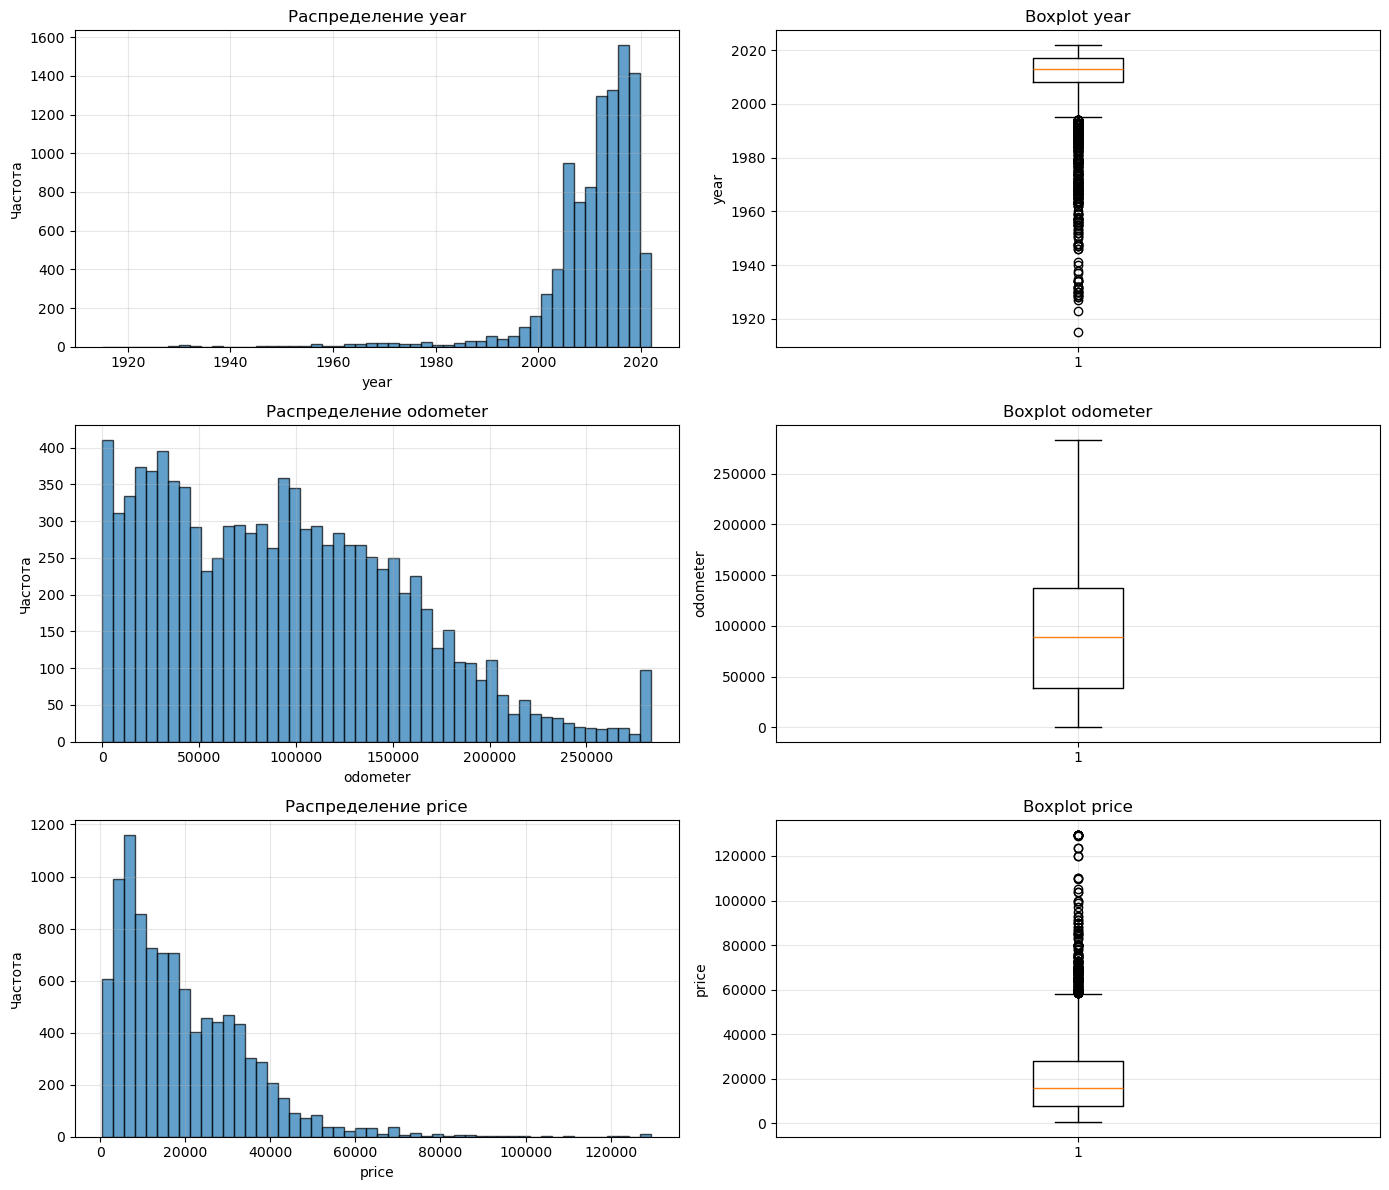

In [89]:
print("анализ числовых признаков")
if numeric_cols:
    fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(14, 4*len(numeric_cols)))
    
    for i, col in enumerate(numeric_cols):
        axes[i, 0].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
        axes[i, 0].set_title(f'Распределение {col}')
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel('Частота')
        axes[i, 0].grid(alpha=0.3)
        
        axes[i, 1].boxplot(df[col], vert=True)
        axes[i, 1].set_title(f'Boxplot {col}')
        axes[i, 1].set_ylabel(col)
        axes[i, 1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 3.2 создаем новы фичи / бинарные флаги

In [90]:
df['car_age'] = 2025 - df['year']

In [91]:
df['odometer_per_year'] = df['odometer'] / df['car_age'].replace(0, 1)

In [92]:
model_freq = df['model'].value_counts(normalize=True)

rare_models = model_freq[model_freq < 20 / len(df)].index
df['model_reduced'] = df['model'].where(~df['model'].isin(rare_models), 'other')

df['manufacturer_model'] = df['manufacturer'] + '_' + df['model_reduced']

top_models = df['model_reduced'].value_counts().head(50).index
df['is_top_model'] = df['model_reduced'].isin(top_models).astype(int)

In [93]:
df['is_gas']      = (df['fuel'] == 'gas').astype(int)
df['is_diesel']   = (df['fuel'] == 'diesel').astype(int)
df['is_hybrid']   = (df['fuel'] == 'hybrid').astype(int)
df['is_electric'] = (df['fuel'] == 'electric').astype(int)

In [94]:
df['is_title_other'] = (df['title_status_reduced'] == 'other').astype(int)

In [95]:
df['is_manual'] = (df['transmission'] == 'manual').astype(int)

In [96]:
top_states = df['state_reduced'].value_counts().head(10).index
for st in top_states:
    df[f'state_{st}'] = (df['state_reduced'] == st).astype(int)

df['state_other'] = (df['state_reduced'] == 'other').astype(int)

In [97]:
print(df.columns.tolist())

['price', 'year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission', 'description', 'state', 'posting_date', 'price_category', 'title_status_reduced', 'state_reduced', 'car_age', 'odometer_per_year', 'model_reduced', 'manufacturer_model', 'is_top_model', 'is_gas', 'is_diesel', 'is_hybrid', 'is_electric', 'is_title_other', 'is_manual', 'state_other', 'state_ca', 'state_fl', 'state_tx', 'state_mi', 'state_ny', 'state_oh', 'state_pa', 'state_nc', 'state_or']


## 3.3 Label encoding для целевой переменной 

In [98]:
le_price = LabelEncoder()
df['price_category_encoded'] = le_price.fit_transform(df['price_category'])

## 3.4 One Hot Encoding

In [99]:
ohe_cols = [
    'manufacturer',
    'fuel',
    'title_status_reduced',
    'transmission',
    'state_reduced'
]

In [100]:
ohe = OneHotEncoder(sparse_output=False, drop='first')  # drop='first' для дамми-ловушки
ohe_array = ohe.fit_transform(df[ohe_cols])
ohe_df = pd.DataFrame(ohe_array, columns=ohe.get_feature_names_out(ohe_cols), index=df.index)

df = pd.concat([df, ohe_df], axis=1)

## 3.5 Frequency Encoding

In [101]:
model_freq = df['model_reduced'].value_counts(normalize=True)
df['model_freq'] = df['model_reduced'].map(model_freq)

## 3.6 Масштабирование числовых признаков

In [102]:
num_cols = [
    'year', 'odometer', 'car_age', 
    'odometer_per_year', 'model_freq'
]

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

## 3.7 Финальный датасет

In [103]:
final_cols = (
    num_cols +
    list(ohe_df.columns) +
    ['is_gas', 'is_diesel', 'is_hybrid', 'is_electric',
     'is_title_other', 'is_manual', 'state_other']
)

In [104]:
df_final = df[final_cols + ['price_category_encoded']].copy()
print("Финальный датасет готов. Размер:", df_final.shape)

Финальный датасет готов. Размер: (9998, 92)


In [105]:
df_final.head()

,year,odometer,car_age,odometer_per_year,model_freq,manufacturer_alfa-romeo,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,...,state_reduced_wa,state_reduced_wi,is_gas,is_diesel,is_hybrid,is_electric,is_title_other,is_manual,state_other,price_category_encoded
0,0.935715,-1.042690,-0.935715,-0.353868,0.638561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,1,0,0,0,0,0,0
1,0.521911,-0.527040,-0.521911,-0.080012,0.638561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,0,0,0,0,0,0,2
2,0.625362,-1.254673,-0.625362,-1.219485,0.638561,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,0,0,0,0,0,0,0
3,0.211558,0.379324,-0.211558,0.640105,-1.571078,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,0,0,0,0,0,0,2
4,1.039165,-1.350393,-1.039165,-1.162896,-1.564510,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1,0,0,0,0,0,0,2


# 4.Modelling

## 4.1 разбивка датасета train/test split

In [106]:
X = df_final.drop(columns=['price_category_encoded']) 
y = df_final['price_category_encoded']                

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4.2 Logistic Regression

In [107]:
lr = LogisticRegression(max_iter=2000, solver='liblinear', random_state=42)
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='accuracy')
print(f"LogisticRegression CV Accuracy: {lr_cv_scores}, Mean: {lr_cv_scores.mean():.4f}")

LogisticRegression CV Accuracy: [0.685      0.6625     0.66625    0.68730457 0.66916823], Mean: 0.6740


In [108]:
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("LogisticRegression Classification Report:\n", classification_report(y_test, y_pred_lr))

LogisticRegression Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.83      0.75       699
           1       0.70      0.78      0.74       645
           2       0.58      0.39      0.47       656

    accuracy                           0.67      2000
   macro avg       0.66      0.67      0.66      2000
weighted avg       0.66      0.67      0.66      2000



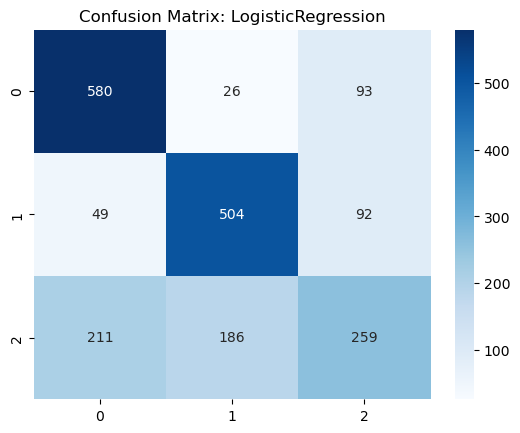

In [109]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: LogisticRegression')
plt.show()

In [110]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000, solver='liblinear'), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
print("Лучшие параметры LogisticRegression:", grid_lr.best_params_)

Лучшие параметры LogisticRegression: {'C': 10}


In [111]:
y_pred_lr_tuned = best_lr.predict(X_test)
print(
    "Точность LogisticRegression на тесте после тюнинга:", 
    accuracy_score(y_test, y_pred_lr_tuned)
)

Точность LogisticRegression на тесте после тюнинга: 0.6715


## 4.3 Random Forest

In [112]:
rf = RandomForestClassifier(random_state=42)
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"RandomForest CV Accuracy: {rf_cv_scores}, Mean: {rf_cv_scores.mean():.4f}")

RandomForest CV Accuracy: [0.73375    0.71375    0.729375   0.72170106 0.72420263], Mean: 0.7246


In [113]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RandomForest Classification Report:\n", classification_report(y_test, y_pred_rf))

RandomForest Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.82      0.80       699
           1       0.73      0.77      0.75       645
           2       0.60      0.55      0.57       656

    accuracy                           0.71      2000
   macro avg       0.70      0.71      0.71      2000
weighted avg       0.71      0.71      0.71      2000



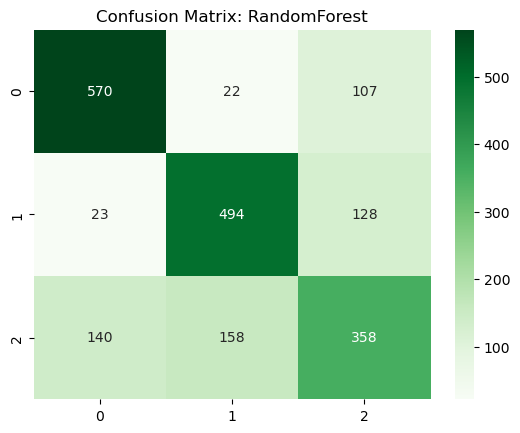

In [114]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix: RandomForest')
plt.show()

In [115]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Лучшие параметры RandomForest:", grid_rf.best_params_)

Лучшие параметры RandomForest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [116]:
y_pred_rf_tuned = best_rf.predict(X_test)

print(
    "Точность на тесте после тюнинга:", 
    accuracy_score(y_test, y_pred_rf_tuned)
)

Точность на тесте после тюнинга: 0.7255


## 4.4 MLPClassifier

In [117]:
mlp = MLPClassifier(max_iter=1000, random_state=42)
mlp_cv_scores = cross_val_score(mlp, X_train, y_train, cv=5, scoring='accuracy')
print(f"MLPClassifier CV Accuracy: {mlp_cv_scores}, Mean: {mlp_cv_scores.mean():.4f}")

MLPClassifier CV Accuracy: [0.69375    0.665625   0.66125    0.64915572 0.67417136], Mean: 0.6688


In [118]:
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print("MLPClassifier Classification Report:\n", classification_report(y_test, y_pred_mlp))

MLPClassifier Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.78      0.76       699
           1       0.69      0.74      0.71       645
           2       0.58      0.50      0.54       656

    accuracy                           0.68      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.67      0.68      0.67      2000



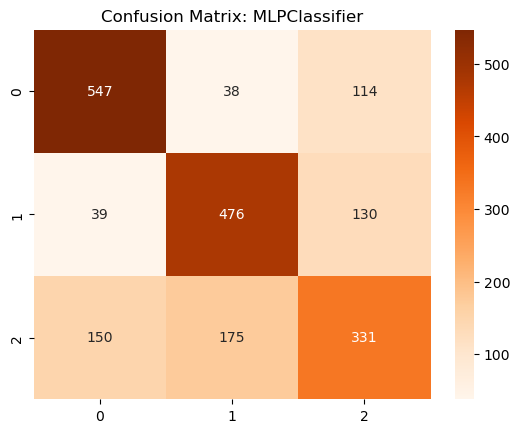

In [119]:
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix: MLPClassifier')
plt.show()

In [120]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (100,50)],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}
grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=42), 
    param_grid_mlp, cv=5, scoring='accuracy', n_jobs=-1)

grid_mlp.fit(X_train, y_train)
best_mlp = grid_mlp.best_estimator_
print("Лучшие параметры MLPClassifier:", grid_mlp.best_params_)

Лучшие параметры MLPClassifier: {'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}


In [121]:
y_pred_mlp_tuned = best_mlp.predict(X_test)
print("Точность на тесте после тюнинга:", accuracy_score(y_test, y_pred_mlp_tuned))

Точность на тесте после тюнинга: 0.674


## 4.5 Сравнение средних CV Accuracy

In [122]:
models = ['LogisticRegression', 'RandomForest', 'MLPClassifier']
cv_means = [lr_cv_scores.mean(), rf_cv_scores.mean(), mlp_cv_scores.mean()]

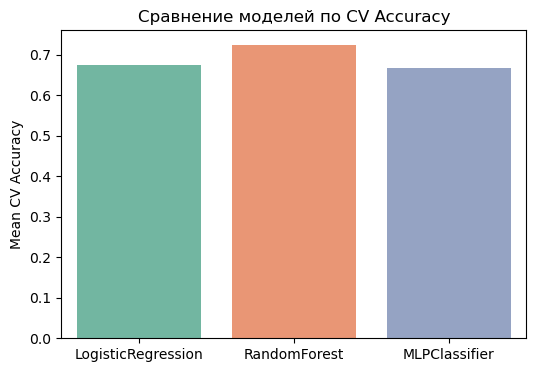

In [123]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x=models, y=cv_means, hue=models, 
    palette='Set2', legend=False
)

plt.ylabel('Mean CV Accuracy')
plt.title('Сравнение моделей по CV Accuracy')
plt.show()

In [124]:
best_model_index = np.argmax(cv_means)
best_model_name = models[best_model_index]
print(f"Лучшая модель по CV Accuracy: {best_model_name}")

Лучшая модель по CV Accuracy: RandomForest


## 4.6 Random Forest — feature importance

In [143]:
importances = best_rf.feature_importances_

rf_importance_df = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': importances
    })
    .sort_values('importance', ascending=False)
)

top_rf_features = rf_importance_df.head(20)
print(top_rf_features)

                    feature  importance
0                      year    0.231610
2                   car_age    0.222426
1                  odometer    0.165352
3         odometer_per_year    0.088870
4                model_freq    0.044816
85                is_diesel    0.036475
24         manufacturer_kia    0.019917
45                 fuel_gas    0.016331
84                   is_gas    0.015269
20     manufacturer_hyundai    0.015088
10   manufacturer_chevrolet    0.013597
42  manufacturer_volkswagen    0.011277
16        manufacturer_ford    0.009009
17         manufacturer_gmc    0.008163
32      manufacturer_nissan    0.008118
36         manufacturer_ram    0.007383
19       manufacturer_honda    0.006961
41      manufacturer_toyota    0.006294
75         state_reduced_or    0.005442
23        manufacturer_jeep    0.004476


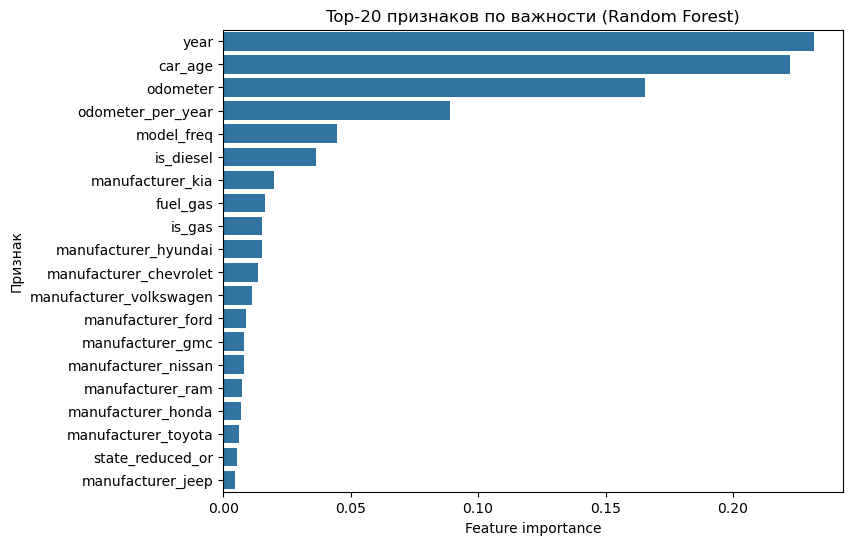

In [145]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=top_rf_features['importance'],
    y=top_rf_features['feature'],
    order=top_rf_features['feature']  
)
plt.title('Top-20 признаков по важности (Random Forest)')
plt.xlabel('Feature importance')
plt.ylabel('Признак')
plt.show()

## 4.7 Проверка переобучения (Random Forest)

In [129]:
train_acc = accuracy_score(y_train, best_rf.predict(X_train))
test_acc = accuracy_score(y_test, best_rf.predict(X_test))

In [130]:
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Разница:        {train_acc - test_acc:.4f}")

Train accuracy: 0.9692
Test accuracy:  0.7255
Разница:        0.2437


In [131]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    n_jobs=-1
)

param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [5, 10, 20],
    'min_samples_split': [10, 20, 50],
    'max_features': ['sqrt', 0.3, 0.5]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("\nЛучшие параметры RandomForest:", grid_rf.best_params_)
print("CV accuracy лучшей модели:", grid_rf.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры RandomForest: {'max_depth': 12, 'max_features': 0.5, 'min_samples_leaf': 5, 'min_samples_split': 10}
CV accuracy лучшей модели: 0.7037979205753596


In [132]:
best_rf = grid_rf.best_estimator_

train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Разница:        {train_acc - test_acc:.4f}")

Train accuracy: 0.7927
Test accuracy:  0.7065
Разница:        0.0862


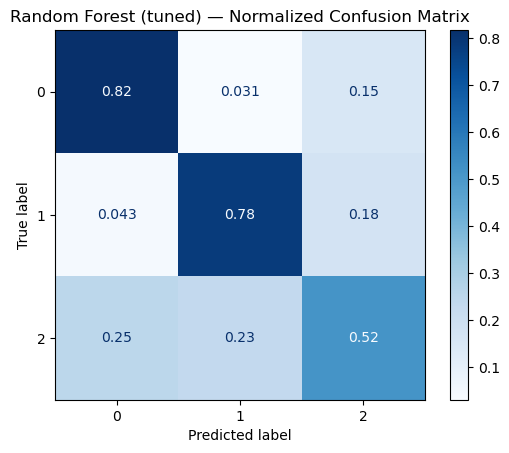

In [133]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap='Blues',
    normalize='true'
)

plt.title("Random Forest (tuned) — Normalized Confusion Matrix")
plt.show()

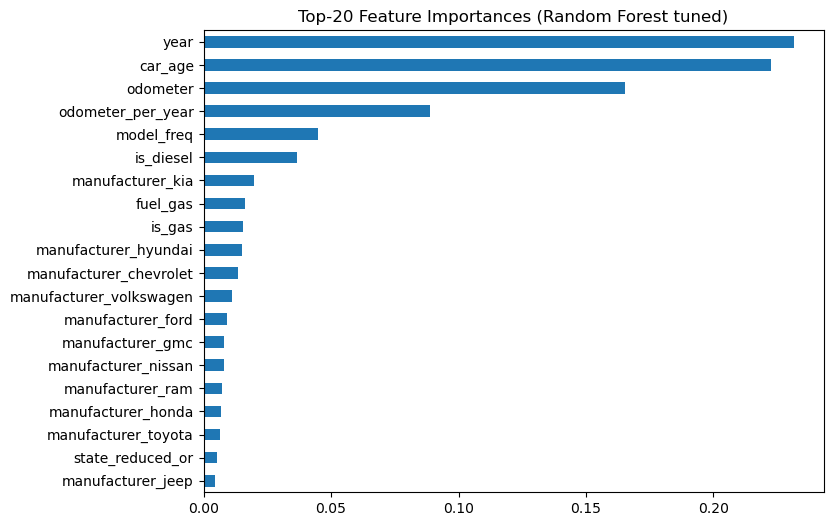

In [134]:
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

importances.plot(kind='barh', figsize=(8, 6))
plt.title("Top-20 Feature Importances (Random Forest tuned)")
plt.gca().invert_yaxis()
plt.show()

# 5. Results

In [135]:
X = df_final.drop(columns=['price_category_encoded'])
y = df_final['price_category_encoded']

In [136]:
final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    max_features=0.5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [137]:
final_model.fit(X, y)
print("Финальная модель обучена на всём датасете")

Финальная модель обучена на всём датасете


In [138]:
model_path = "final_random_forest_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

print(f"Модель сохранена в файл: {model_path}")

Модель сохранена в файл: final_random_forest_model.pkl


В рамках задачи классификации цен автомобилей была проведена подготовка данных, feature engineering и сравнение трёх моделей: логистической регрессии, случайного леса и многослойного персептрона.

Лучшие результаты показал RandomForestClassifier, который после тюнинга продемонстрировал наилучшее качество на кросс-валидации и тестовой выборке без выраженного переобучения.

Финальная модель была обучена на всём доступном датасете и сохранена для дальнейшего использования.
